# Prepare enviroment

In [1]:
import nltk
import spacy
import textstat
import tiktoken

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import RegexpTokenizer, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from lexicalrichness import LexicalRichness
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import pdist

from config import LLM_RESULTS_TEST_PROMPTS, TRAIN_PROMPTS, TEST_PROMPTS, VAL_PROMPTS

# Load data

In [2]:
llm_results_test_prompts_df = pd.read_csv(LLM_RESULTS_TEST_PROMPTS)

train_prompts_df = pd.read_csv(TRAIN_PROMPTS, sep=";")
test_prompts_df = pd.read_csv(TEST_PROMPTS, sep=";")
val_prompts_df = pd.read_csv(VAL_PROMPTS, sep=";")

# Analyze LLM responses

## Results for test prompts
Path to prompts: *../data/prompts/test_prompts.csv*

In [3]:
llm_results_test_prompts_df.head(5)

,run_id,prompt_id,category,prompt_column,language,is_paraphrase,prompt_text,model_key,model_id,provider,...,response,error,response_length,elapsed_seconds,logprob_available,sum_logprob,avg_logprob,generated_tokens,perplexity,timestamp
0,1,EXP_T01,wyjaśniające,prompt_en,en,False,Explain to a non-technical person why cloud st...,gemini-flash-latest,gemini-flash-latest,Google Gemini API,...,"To understand the difference, it helps to thin...",NaN,2849,8.65,False,NaN,NaN,0,NaN,2026-04-23T14:44:09.679427
1,1,EXP_T01,wyjaśniające,prompt_en,en,False,Explain to a non-technical person why cloud st...,llama-3.1-8b-groq,llama-3.1-8b-instant,Groq API,...,Imagine you have a big box where you store all...,NaN,2110,1.53,False,NaN,NaN,0,NaN,2026-04-23T14:44:11.712855
2,1,EXP_T01,wyjaśniające,prompt_en,en,False,Explain to a non-technical person why cloud st...,mistral-7b-hf,mistralai/Mistral-7B-Instruct-v0.3,HuggingFace (local GPU),...,"Cloud storage, while providing a convenient an...",NaN,1907,37.85,True,-59.209320,-0.153392,386,1.165782,2026-04-23T14:44:50.061568
3,1,EXP_T01,wyjaśniające,prompt_en,en,False,Explain to a non-technical person why cloud st...,phi-3-mini-hf,microsoft/Phi-3-mini-4k-instruct,HuggingFace (local GPU),...,Imagine you have an important document that's ...,NaN,1464,22.37,True,-96.367848,-0.318046,303,1.374439,2026-04-23T14:45:12.435303
4,1,EXP_T01,wyjaśniające,prompt_pl,pl,False,"Wyjaśnij osobie nietechnicznej, dlaczego przec...",gemini-flash-latest,gemini-flash-latest,Google Gemini API,...,"To częsty błąd: myślimy, że skoro nasze pliki ...",NaN,3133,10.24,False,NaN,NaN,0,NaN,2026-04-23T14:45:22.674541


In [4]:
num_of_rows, num_of_columns = llm_results_test_prompts_df.shape
print(f"Number of rows: {num_of_rows}, Number of columns: {num_of_columns}")

Number of rows: 480, Number of columns: 26


In [5]:
llm_results_test_prompts_df.columns

Index(['run_id', 'prompt_id', 'category', 'prompt_column', 'language',
       'is_paraphrase', 'prompt_text', 'model_key', 'model_id', 'provider',
       'model_parameters', 'temperature', 'top_p', 'max_tokens',
       'max_new_tokens', 'repetition_penalty', 'response', 'error',
       'response_length', 'elapsed_seconds', 'logprob_available',
       'sum_logprob', 'avg_logprob', 'generated_tokens', 'perplexity',
       'timestamp'],
      dtype='str')

In [6]:
llm_results_test_prompts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   run_id              480 non-null    int64  
 1   prompt_id           480 non-null    str    
 2   category            480 non-null    str    
 3   prompt_column       480 non-null    str    
 4   language            480 non-null    str    
 5   is_paraphrase       480 non-null    bool   
 6   prompt_text         480 non-null    str    
 7   model_key           480 non-null    str    
 8   model_id            480 non-null    str    
 9   provider            480 non-null    str    
 10  model_parameters    480 non-null    str    
 11  temperature         480 non-null    float64
 12  top_p               480 non-null    float64
 13  max_tokens          240 non-null    float64
 14  max_new_tokens      240 non-null    float64
 15  repetition_penalty  240 non-null    float64
 16  response           

In [7]:
llm_results_test_prompts_df.describe()

,run_id,temperature,top_p,max_tokens,max_new_tokens,repetition_penalty,response_length,elapsed_seconds,sum_logprob,avg_logprob,generated_tokens,perplexity
count,480.0,4.800000e+02,4.800000e+02,240.0,240.0,2.400000e+02,480.000000,480.000000,240.000000,240.000000,480.000000,240.000000
mean,1.0,3.000000e-01,9.000000e-01,3072.0,3072.0,1.100000e+00,2400.214583,37.298271,-200.112188,-0.179224,466.527083,1.200668
std,0.0,5.556907e-17,2.222763e-16,0.0,0.0,2.225086e-16,3416.520721,59.715033,290.855039,0.084844,812.302865,0.104905
min,1.0,3.000000e-01,9.000000e-01,3072.0,3072.0,1.100000e+00,0.000000,0.120000,-1223.101848,-0.398145,0.000000,1.013889
25%,1.0,3.000000e-01,9.000000e-01,3072.0,3072.0,1.100000e+00,499.250000,0.587500,-166.628403,-0.233575,0.000000,1.120309
50%,1.0,3.000000e-01,9.000000e-01,3072.0,3072.0,1.100000e+00,1569.500000,10.315000,-80.793363,-0.152359,20.500000,1.164578
75%,1.0,3.000000e-01,9.000000e-01,3072.0,3072.0,1.100000e+00,2602.250000,48.375000,-48.470342,-0.113604,576.500000,1.263107
max,1.0,3.000000e-01,9.000000e-01,3072.0,3072.0,1.100000e+00,19766.000000,238.970000,-7.833139,-0.013793,3072.000000,1.489060


In [8]:
llm_results_test_prompts_df["run_id"].value_counts()

run_id
1    480
Name: count, dtype: int64

In [9]:
llm_results_test_prompts_df["prompt_id"].value_counts()

prompt_id
EXP_T01    16
EXP_T02    16
EXP_T03    16
EXP_T04    16
EXP_T05    16
CMP_T01    16
CMP_T02    16
CMP_T03    16
CMP_T04    16
CMP_T05    16
ARG_T01    16
ARG_T02    16
ARG_T03    16
ARG_T04    16
ARG_T05    16
PRC_T01    16
PRC_T02    16
PRC_T03    16
PRC_T04    16
PRC_T05    16
INT_T01    16
INT_T02    16
INT_T03    16
INT_T04    16
INT_T05    16
TRK_T01    16
TRK_T02    16
TRK_T03    16
TRK_T04    16
TRK_T05    16
Name: count, dtype: int64

In [10]:
llm_results_test_prompts_df.value_counts(["prompt_id", "prompt_text"])

prompt_id  prompt_text                                                                                                                                                                     
EXP_T01    Explain to a non-technical person why cloud storage does not eliminate the need for backups.                                                                                        4
           Wyjaśnij osobie nietechnicznej, dlaczego przechowywanie plików w chmurze nie eliminuje potrzeby tworzenia kopii zapasowych.                                                         4
           A person thinks that storing files in the cloud is enough protection. Explain why backups are still necessary.                                                                      4
           Pewna osoba uważa, że samo trzymanie plików w chmurze wystarcza. Wyjaśnij, dlaczego kopie zapasowe nadal są potrzebne.                                                              4
EXP_T02    Explain in simple terms why c

In [11]:
llm_results_test_prompts_df["category"].value_counts()

category
wyjaśniające                 80
porównawcze                  80
argumentacyjno-decyzyjne     80
proceduralne                 80
interpretacyjne              80
transformacja_lub_krytyka    80
Name: count, dtype: int64

In [12]:
llm_results_test_prompts_df.value_counts(["prompt_id", "category"])

prompt_id  category                 
EXP_T01    wyjaśniające                 16
EXP_T02    wyjaśniające                 16
EXP_T03    wyjaśniające                 16
EXP_T04    wyjaśniające                 16
EXP_T05    wyjaśniające                 16
CMP_T01    porównawcze                  16
CMP_T02    porównawcze                  16
CMP_T03    porównawcze                  16
CMP_T04    porównawcze                  16
CMP_T05    porównawcze                  16
ARG_T01    argumentacyjno-decyzyjne     16
ARG_T02    argumentacyjno-decyzyjne     16
ARG_T03    argumentacyjno-decyzyjne     16
ARG_T04    argumentacyjno-decyzyjne     16
ARG_T05    argumentacyjno-decyzyjne     16
PRC_T01    proceduralne                 16
PRC_T02    proceduralne                 16
PRC_T03    proceduralne                 16
PRC_T04    proceduralne                 16
PRC_T05    proceduralne                 16
INT_T01    interpretacyjne              16
INT_T02    interpretacyjne              16
INT_T03    interp

In [13]:
llm_results_test_prompts_df.value_counts(["prompt_column", "language", "is_paraphrase"])

prompt_column  language  is_paraphrase
prompt_en      en        False            120
prompt_pl      pl        False            120
paraphrase_en  en        True             120
paraphrase_pl  pl        True             120
Name: count, dtype: int64

In [14]:
llm_results_test_prompts_df.value_counts(["model_id", "model_key", "provider", "model_parameters"])

model_id                            model_key            provider                 model_parameters                                                       
gemini-flash-latest                 gemini-flash-latest  Google Gemini API        temperature=0.3, top_p=0.9, max_tokens=3072                                120
llama-3.1-8b-instant                llama-3.1-8b-groq    Groq API                 temperature=0.3, top_p=0.9, max_tokens=3072                                120
mistralai/Mistral-7B-Instruct-v0.3  mistral-7b-hf        HuggingFace (local GPU)  temperature=0.3, top_p=0.9, max_new_tokens=3072, repetition_penalty=1.1    120
microsoft/Phi-3-mini-4k-instruct    phi-3-mini-hf        HuggingFace (local GPU)  temperature=0.3, top_p=0.9, max_new_tokens=3072, repetition_penalty=1.1    120
Name: count, dtype: int64

In [15]:
llm_results_test_prompts_df.value_counts(["model_parameters"])

model_parameters                                                       
temperature=0.3, top_p=0.9, max_tokens=3072                                240
temperature=0.3, top_p=0.9, max_new_tokens=3072, repetition_penalty=1.1    240
Name: count, dtype: int64

In [16]:
llm_results_test_prompts_df.value_counts(["temperature"])

temperature
0.3            480
Name: count, dtype: int64

In [17]:
llm_results_test_prompts_df.value_counts(["top_p"])

top_p
0.9      480
Name: count, dtype: int64

In [18]:
llm_results_test_prompts_df.value_counts(["max_tokens"])

max_tokens
3072.0        240
Name: count, dtype: int64

In [19]:
llm_results_test_prompts_df.value_counts(["max_new_tokens"])

max_new_tokens
3072.0            240
Name: count, dtype: int64

In [20]:
llm_results_test_prompts_df.value_counts(["repetition_penalty"])

repetition_penalty
1.1                   240
Name: count, dtype: int64

In [21]:
print(f"Number of unique responses: {llm_results_test_prompts_df["response"].nunique()} (not counting NaN)")
print(f"Number of missing responses: {llm_results_test_prompts_df['response'].isna().sum()}")

Number of unique responses: 374 (not counting NaN)
Number of missing responses: 106


In [22]:
llm_results_test_prompts_df.value_counts(["error"])

error                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [23]:
print(f"Number of unique errors: {llm_results_test_prompts_df['error'].nunique()} (not counting NaN)")
print(f"Number of missing errors: {llm_results_test_prompts_df['error'].isna().sum()}")

Number of unique errors: 106 (not counting NaN)
Number of missing errors: 374


In [24]:
llm_results_test_prompts_df.value_counts(["response_length"])

response_length
0                  106
2849                 2
1705                 2
1515                 2
2183                 2
                  ... 
1848                 1
1030                 1
511                  1
254                  1
677                  1
Name: count, Length: 357, dtype: int64

In [25]:
llm_results_test_prompts_df.value_counts(["elapsed_seconds"])

elapsed_seconds
0.16               21
0.15               20
0.17               11
0.33                8
0.20                7
                   ..
56.01               1
21.33               1
7.69                1
14.98               1
13.48               1
Name: count, Length: 352, dtype: int64

In [26]:
llm_results_test_prompts_df.value_counts(["logprob_available"])

logprob_available
False                240
True                 240
Name: count, dtype: int64

In [27]:
llm_results_test_prompts_df.value_counts(["sum_logprob"])

sum_logprob
-59.209320     1
-96.367848     1
-86.365307     1
-139.264966    1
-48.450385     1
              ..
-177.465414    1
-31.206434     1
-13.538725     1
-22.054006     1
-52.940639     1
Name: count, Length: 240, dtype: int64

In [28]:
llm_results_test_prompts_df.value_counts(["avg_logprob"])

avg_logprob
-0.112191      2
-0.153392      1
-0.318046      1
-0.107822      1
-0.219315      1
              ..
-0.234433      1
-0.136273      1
-0.130180      1
-0.144144      1
-0.295758      1
Name: count, Length: 239, dtype: int64

In [29]:
llm_results_test_prompts_df.value_counts(["generated_tokens"])

generated_tokens
0                   240
3072                 29
386                   3
801                   2
345                   2
                   ... 
242                   1
757                   1
229                   1
104                   1
153                   1
Name: count, Length: 198, dtype: int64

In [30]:
llm_results_test_prompts_df.value_counts(["perplexity"])

perplexity
1.118726      2
1.165782      1
1.374439      1
1.113849      1
1.245223      1
             ..
1.264191      1
1.145994      1
1.139033      1
1.155050      1
1.344145      1
Name: count, Length: 239, dtype: int64

In [31]:
llm_results_test_prompts_df.value_counts(["timestamp"])

timestamp                 
2026-04-23T14:44:09.679427    1
2026-04-23T14:44:11.712855    1
2026-04-23T14:44:50.061568    1
2026-04-23T14:45:12.435303    1
2026-04-23T14:45:22.674541    1
                             ..
2026-04-23T19:43:54.473800    1
2026-04-23T19:43:54.624220    1
2026-04-23T19:43:55.509174    1
2026-04-23T19:44:10.989129    1
2026-04-23T19:44:24.466650    1
Name: count, Length: 480, dtype: int64

## Correlation heatmap for numeric columns

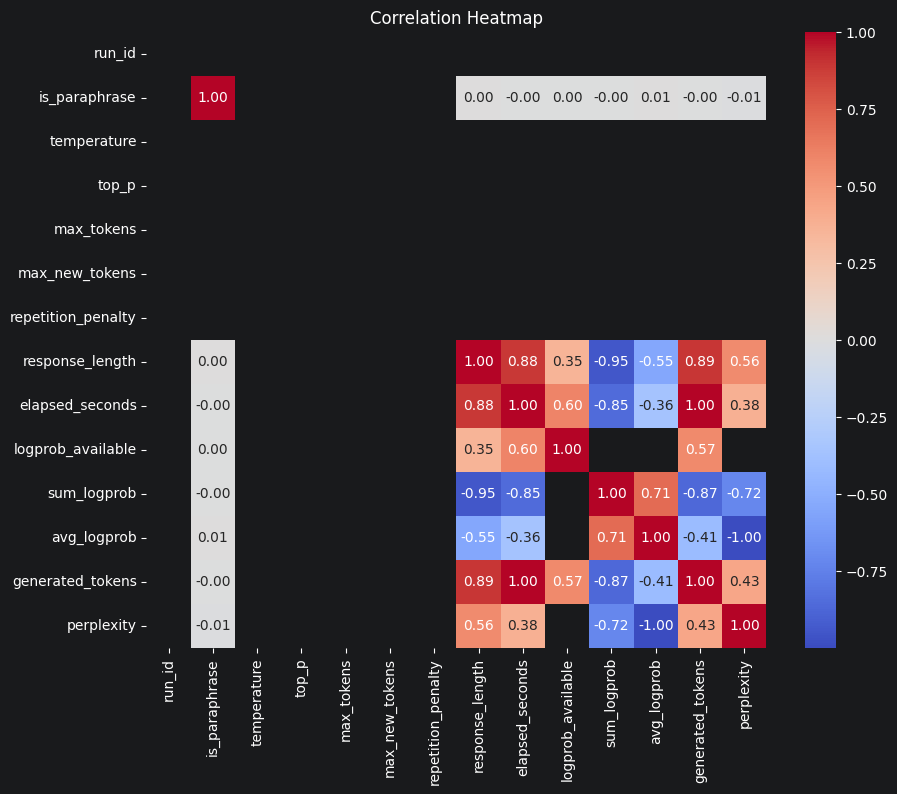

In [32]:
corr = llm_results_test_prompts_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# Create response features

In [43]:
response_features = llm_results_test_prompts_df[["prompt_id", "category", "language", "is_paraphrase", "model_key", "provider", "response", "elapsed_seconds"]].copy()

response_features["response"] = response_features["response"].fillna("")

In [44]:
response_features

,prompt_id,category,language,is_paraphrase,model_key,provider,response,elapsed_seconds
0,EXP_T01,wyjaśniające,en,False,gemini-flash-latest,Google Gemini API,"To understand the difference, it helps to thin...",8.65
1,EXP_T01,wyjaśniające,en,False,llama-3.1-8b-groq,Groq API,Imagine you have a big box where you store all...,1.53
2,EXP_T01,wyjaśniające,en,False,mistral-7b-hf,HuggingFace (local GPU),"Cloud storage, while providing a convenient an...",37.85
3,EXP_T01,wyjaśniające,en,False,phi-3-mini-hf,HuggingFace (local GPU),Imagine you have an important document that's ...,22.37
4,EXP_T01,wyjaśniające,pl,False,gemini-flash-latest,Google Gemini API,"To częsty błąd: myślimy, że skoro nasze pliki ...",10.24
...,...,...,...,...,...,...,...,...
475,TRK_T05,transformacja_lub_krytyka,en,True,phi-3-mini-hf,HuggingFace (local GPU),"Dear Team,\n\nI hope you're all doing well. I ...",7.69
476,TRK_T05,transformacja_lub_krytyka,pl,True,gemini-flash-latest,Google Gemini API,,0.15
477,TRK_T05,transformacja_lub_krytyka,pl,True,llama-3.1-8b-groq,Groq API,"Czy mogę poprosić o Twoją pomoc? Pliki, które ...",0.38
478,TRK_T05,transformacja_lub_krytyka,pl,True,mistral-7b-hf,HuggingFace (local GPU),"Dear [Colleague's Name],\n\nI hope this messag...",14.98


## Create quantitative features

In [45]:
def count_sentences(text: str) -> int:
    if not text:
        return 0

    sentences = sent_tokenize(text)

    return len(sentences)

In [46]:
def get_list_of_words(text: str) -> list[str]:
    if not text:
        return []

    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text.lower())

    return tokens

In [47]:
responses = llm_results_test_prompts_df["response"].fillna("")

response_features["response_length"] = responses.str.len()
response_features["response_number_of_words"] = responses.apply(lambda x: len(get_list_of_words(x)))
response_features["response_number_of_unique_words"] = responses.apply(lambda x: len(set(get_list_of_words(x))))
response_features["response_number_of_sentences"] = responses.apply(count_sentences)

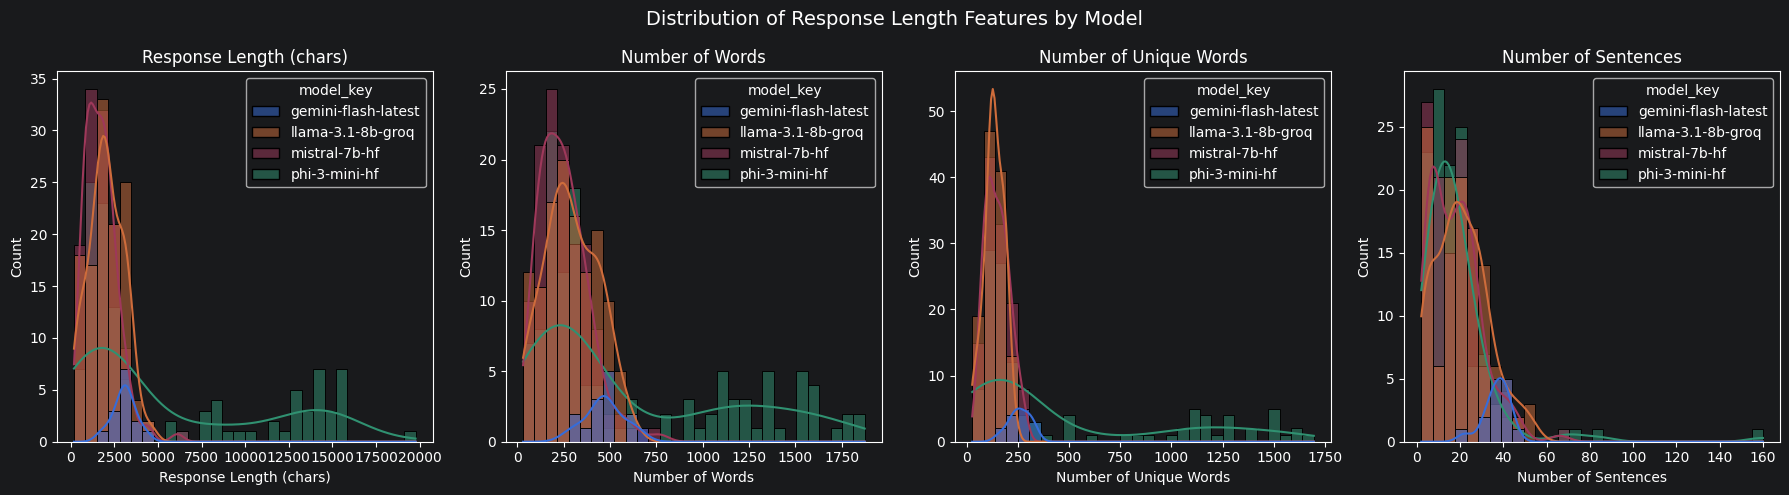

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

features = ["response_length", "response_number_of_words", "response_number_of_unique_words", "response_number_of_sentences"]
titles = ["Response Length (chars)", "Number of Words", "Number of Unique Words", "Number of Sentences"]

for ax, feature, title in zip(axes, features, titles):
    sns.histplot(
        data=response_features[response_features[feature] > 0],
        x=feature, hue="model_key", kde=True, ax=ax, bins=30, alpha=0.5
    )
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Response Length Features by Model", fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
response_features["avg_word_length"] = (
    response_features["response_length"] /
    response_features["response_number_of_words"].replace(0, 1)
)

response_features["avg_words_per_sentence"] = (
    response_features["response_number_of_words"] /
    response_features["response_number_of_sentences"].replace(0, 1)
)

response_features["avg_sentence_length"] = (
    response_features["response_length"] /
    response_features["response_number_of_sentences"].replace(0, 1)
)

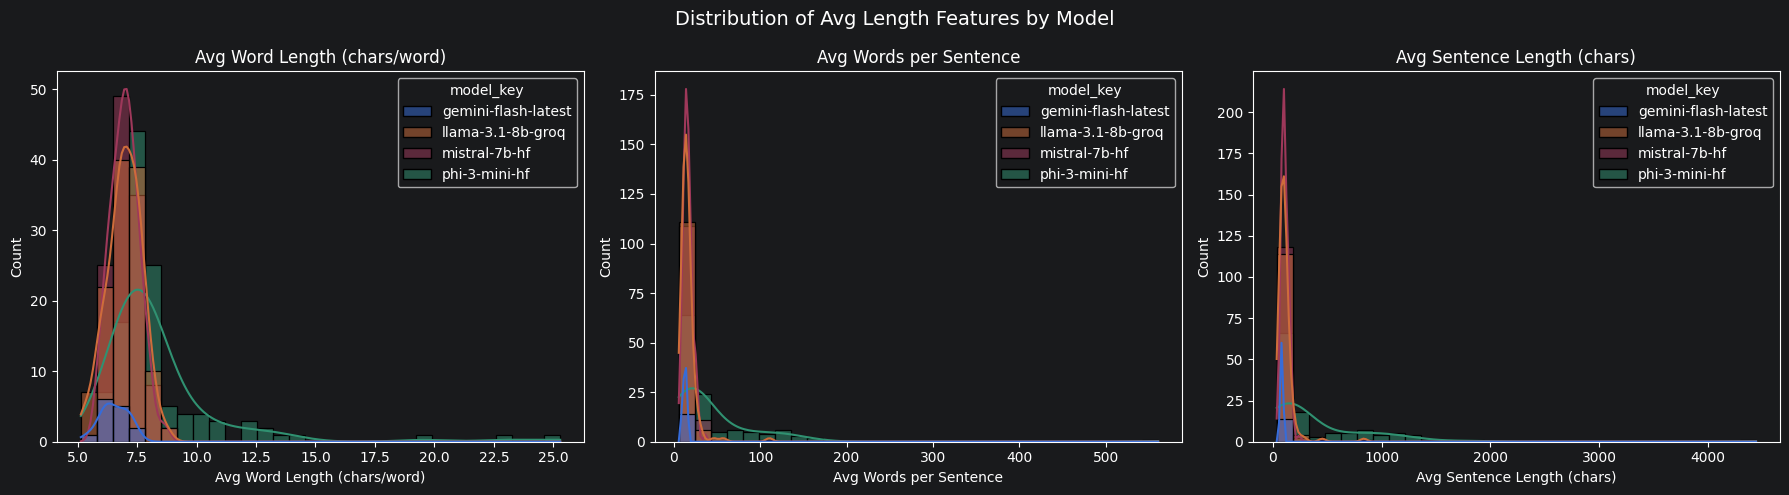

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["avg_word_length", "avg_words_per_sentence", "avg_sentence_length"]
titles = ["Avg Word Length (chars/word)", "Avg Words per Sentence", "Avg Sentence Length (chars)"]

for ax, feature, title in zip(axes, features, titles):
    sns.histplot(
        data=response_features[response_features["response_length"] > 0],
        x=feature, hue="model_key", kde=True, ax=ax, bins=30, alpha=0.5
    )
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Avg Length Features by Model", fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
def get_token_count(text: str) -> int:
    if not text:
        return 0

    enc = tiktoken.get_encoding("o200k_base")
    tokens = enc.encode(text)

    return len(tokens)

In [52]:
response_features["token_count"] = responses.apply(get_token_count)

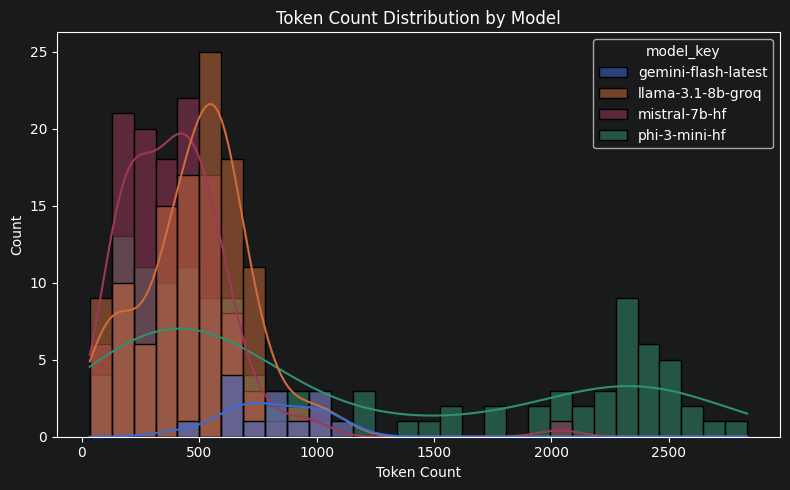

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["token_count"] > 0],
    x="token_count", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Token Count Distribution by Model")
ax.set_xlabel("Token Count")
plt.tight_layout()
plt.show()

## Lexical Diversity Features
### Create Type-Token Ratio feature

Formula:
$$
TTR = \frac{V}{N}
$$

Where:
- $V$ = number of unique words
- $N$ = total number of words

In [44]:
def prepare_text_stats(text):
    words = get_list_of_words(text)
    N = len(words)

    word_frequency = Counter(words)
    V = len(word_frequency)

    return words, N, word_frequency, V

In [45]:
def ttr(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    return V / N if N > 0 else 0

In [46]:
response_features["type_token_ratio"] = responses.apply(ttr)

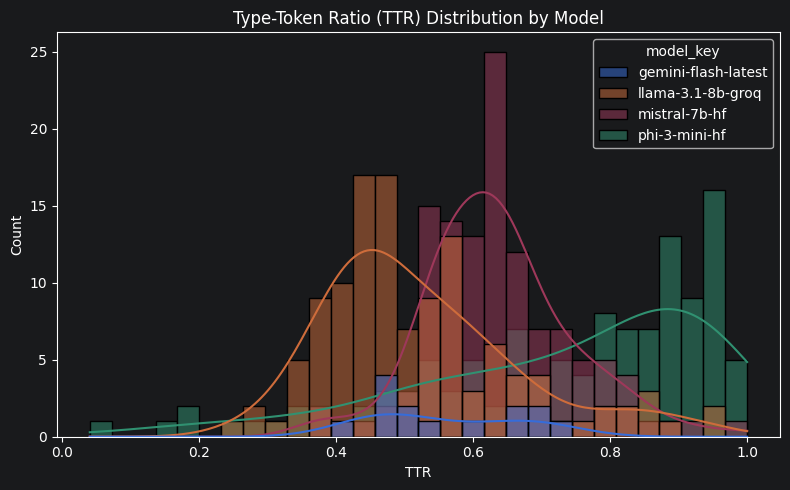

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["type_token_ratio"] > 0],
    x="type_token_ratio", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Type-Token Ratio (TTR) Distribution by Model")
ax.set_xlabel("TTR")
plt.tight_layout()
plt.show()

### Create Yule’s K feature

Formula
$$K = 10^4 \cdot \frac{\sum_{i=1}^{\infty} i^2 f_i - N}{N^2}$$

Where:
- $N$ = total number of words
- $f_i$ = number of words that appear exactly $i$ times

In [48]:
def yule_k(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0:
        return 0

    freq_of_freq = Counter(word_frequency.values())
    sum_i2_fi = sum((i**2) * fi for i, fi in freq_of_freq.items())

    return 1e4 * (sum_i2_fi - N) / (N**2)

In [49]:
response_features["yule_k"] = responses.apply(yule_k)

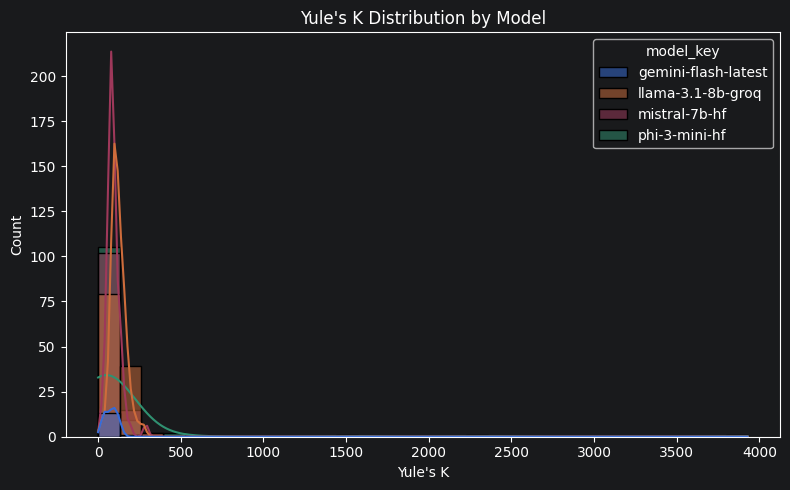

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["yule_k"] > 0],
    x="yule_k", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Yule's K Distribution by Model")
ax.set_xlabel("Yule's K")
plt.tight_layout()
plt.show()

### Create Guiraud’s R feature
Formula:
$$
R = \frac{V}{\sqrt{N}}
$$

Where:
- $V$ = number of unique words
- $N$ = total number of words

In [51]:
def guiraud(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    return V / np.sqrt(N) if N > 0 else 0

In [52]:
response_features["guiraud"] = responses.apply(guiraud)

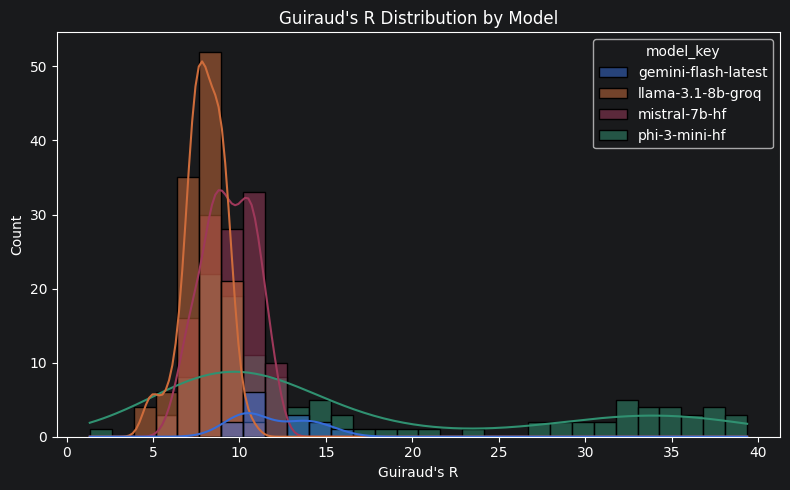

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["guiraud"] > 0],
    x="guiraud", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Guiraud's R Distribution by Model")
ax.set_xlabel("Guiraud's R")
plt.tight_layout()
plt.show()

### Create Honore’s H feature
Formula:
$$
H = 100 * \frac{\log N}{1 - \frac{V_1}{V}}
$$

Where:
- $N$ = total number of words
- $V$ = number of unique words
- $V_1$ = number of words that appear exactly once

In [54]:
def honore(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0 or V == 0:
        return 0

    V1 = sum(1 for c in word_frequency.values() if c == 1)

    if V == V1:
        return 0

    return 100 * np.log(N) / (1 - V1 / V)

In [55]:
response_features["honore"] = responses.apply(honore)

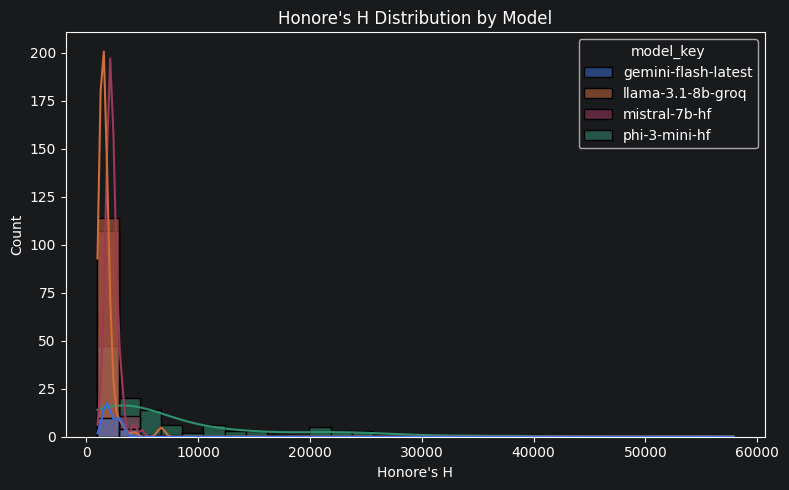

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["honore"] > 0],
    x="honore", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Honore's H Distribution by Model")
ax.set_xlabel("Honore's H")
plt.tight_layout()
plt.show()

### Create Brunet’s W feature
Formula:
$$
W = N^{V^{-a}}
$$
Where:
- $N$ = total number of words
- $V$ = number of unique words
- $a$ = a parameter, often set to $0.165$

In [57]:
def brunet(text, a=0.165):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0 or V == 0:
        return 0

    return N ** (V ** (-a))

In [58]:
response_features["brunet"] = responses.apply(brunet)

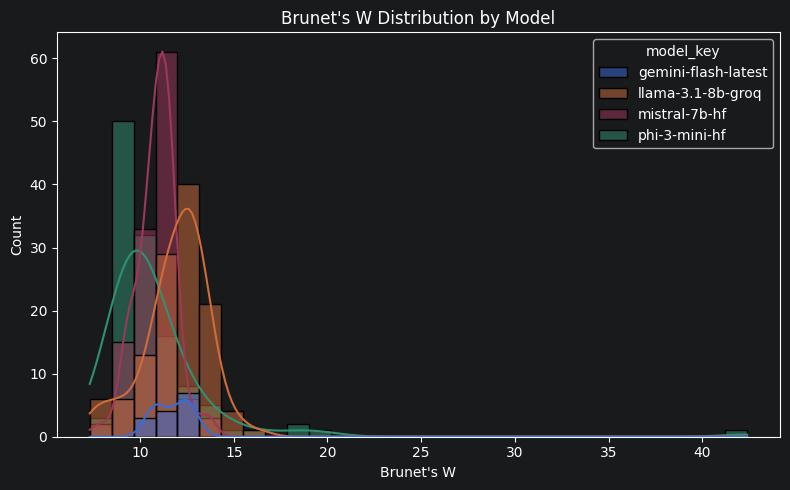

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["brunet"] > 0],
    x="brunet", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Brunet's W Distribution by Model")
ax.set_xlabel("Brunet's W")
plt.tight_layout()
plt.show()

### Create Dugast’s U feature
Formula:
$$
U = \frac{(\log N)^2}{\log N - \log V}
$$

Where:
- $N$ = total number of words
- $V$ = number of unique words

In [60]:
def dugast(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0 or V == 0 or V == N:
        return 0

    return (np.log(N) ** 2) / (np.log(N) - np.log(V))

In [61]:
response_features["dugast"] = responses.apply(dugast)

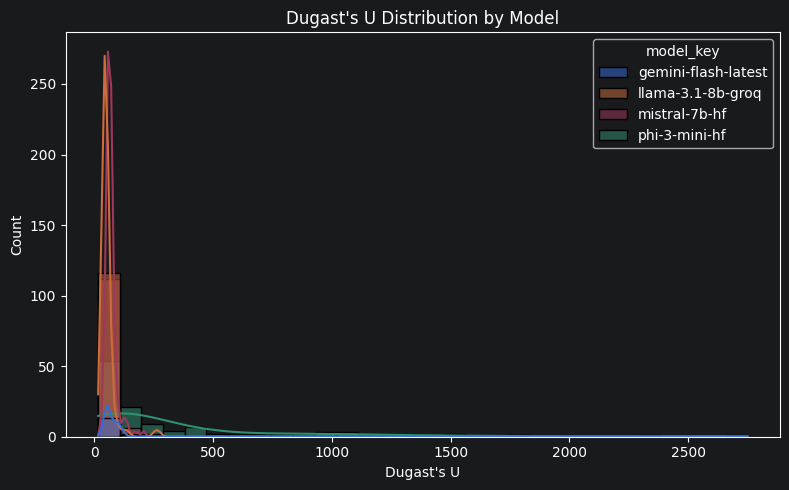

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["dugast"] > 0],
    x="dugast", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Dugast's U Distribution by Model")
ax.set_xlabel("Dugast's U")
plt.tight_layout()
plt.show()

### Create Maas’s a^2 feature
Formula:
$$
a^2 = \frac{\log N - \log V}{(\log N)^2}
$$
Where:
- $N$ = total number of words
- $V$ = number of unique words

In [63]:
def maas_a2(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0 or V == 0:
        return 0

    return (np.log(N) - np.log(V)) / (np.log(N) ** 2)

In [64]:
response_features["maas_a2"] = responses.apply(maas_a2)

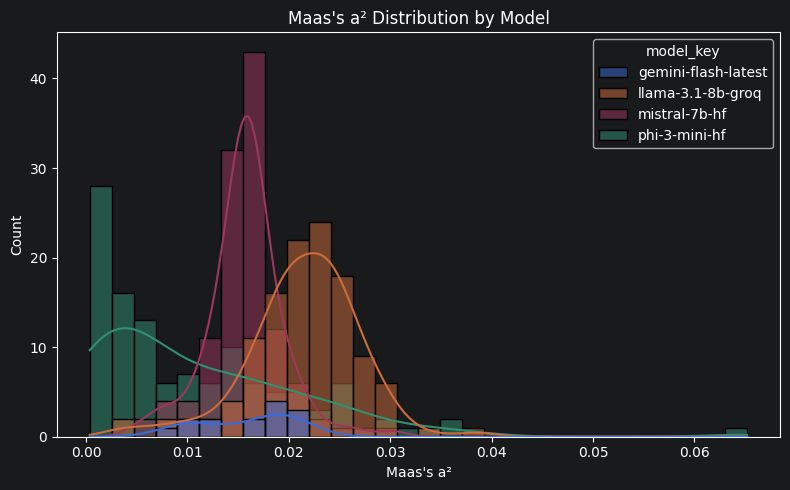

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["maas_a2"] > 0],
    x="maas_a2", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Maas's a² Distribution by Model")
ax.set_xlabel("Maas's a²")
plt.tight_layout()
plt.show()

### Create entropy feature
Formula:
$$H = -\sum_{i=1}^{V} p_i \log(p_i)$$

Where:
- $V$ = number of unique words
- $p_i$ = probability of the $i$-th unique word (frequency of the word divided by total number of words)

In [66]:
def entropy(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0:
        return 0

    probs = np.array(list(word_frequency.values())) / N

    return -np.sum(probs * np.log(probs))

In [67]:
response_features["entropy"] = responses.apply(entropy)

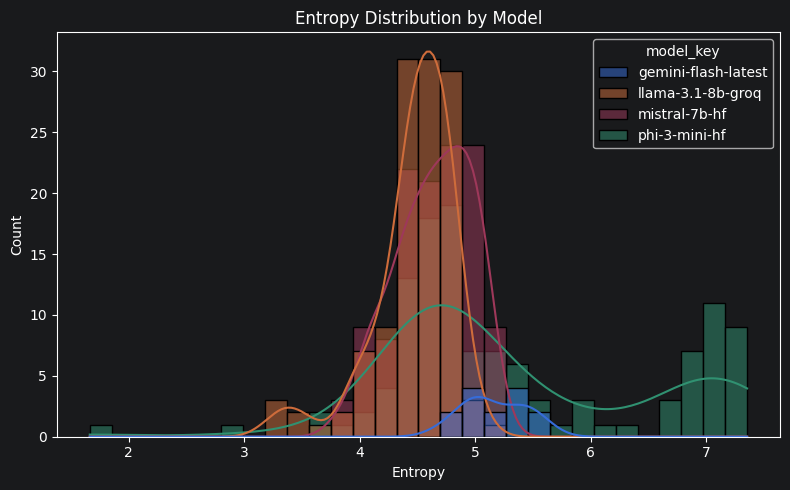

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["entropy"] > 0],
    x="entropy", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Entropy Distribution by Model")
ax.set_xlabel("Entropy")
plt.tight_layout()
plt.show()

### Create repetition rate feature
Formula:
$$R = 1 - \frac{V}{N}$$

Where:
- $V$ = number of unique words
- $N$ = total number of words

In [69]:
def repetition_rate(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    return 1 - (V / N) if N > 0 else 0

In [70]:
response_features["repetition_rate"] = responses.apply(repetition_rate)

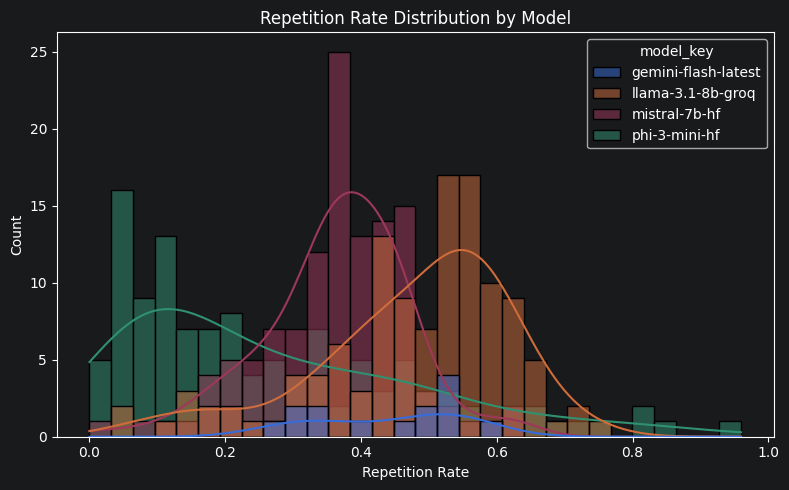

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["response_length"] > 0],
    x="repetition_rate", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Repetition Rate Distribution by Model")
ax.set_xlabel("Repetition Rate")
plt.tight_layout()
plt.show()

### Create hapax ratio feature
Formula:
$$HR = \frac{V_1}{N}$$
Where:
- $N$ = total number of words
- $V$ = number of unique words
- $V_1$ = number of words that appear exactly once

In [72]:
def hapax_ratio(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    if N == 0:
        return 0

    hapax = sum(1 for c in word_frequency.values() if c == 1)

    return hapax / N

In [73]:
response_features["hapax_ratio"] = responses.apply(hapax_ratio)

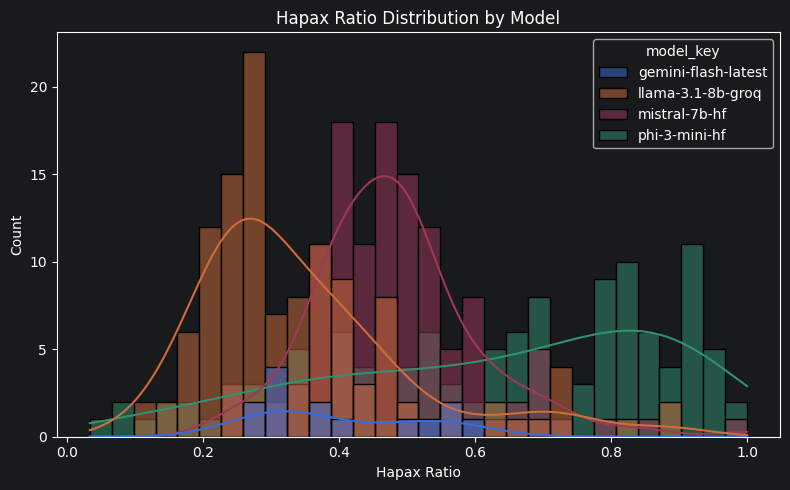

In [74]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["hapax_ratio"] > 0],
    x="hapax_ratio", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Hapax Ratio Distribution by Model")
ax.set_xlabel("Hapax Ratio")
plt.tight_layout()
plt.show()

### Create average word frequency feature
Formula:
$$\bar{f} = \frac{1}{V} \sum_{i=1}^{V} f_i$$

Where:
- $V$ = number of unique words
- $f_i$ = frequency of the $i$-th unique word

In [75]:
def avg_word_freq(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    return np.mean(list(word_frequency.values())) if word_frequency else 0

In [76]:
response_features["avg_word_freq"] = responses.apply(avg_word_freq)

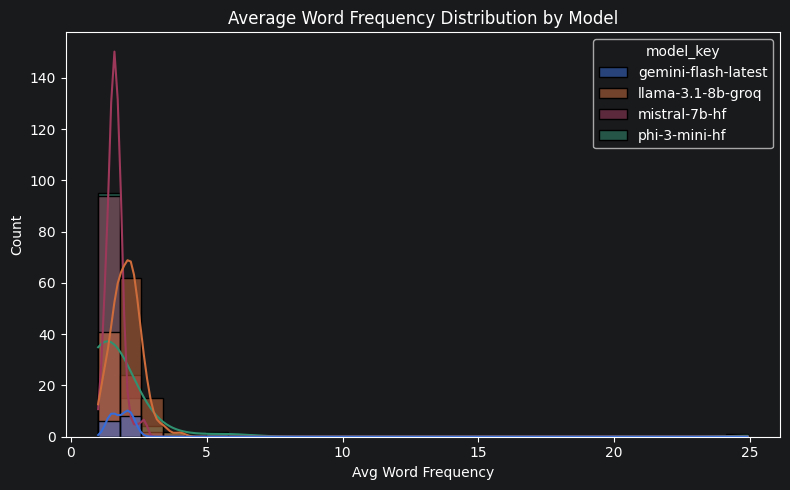

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["avg_word_freq"] > 0],
    x="avg_word_freq", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Average Word Frequency Distribution by Model")
ax.set_xlabel("Avg Word Frequency")
plt.tight_layout()
plt.show()

### Create max word frequency feature
Formula:
$$f_{max} = \max_{1 \leq i \leq V} f_i$$
Where:
- $V$ = number of unique words
- $f_i$ = frequency of the $i$-th unique word

In [78]:
def max_word_freq(text):
    words, N, word_frequency, V = prepare_text_stats(text)

    return max(word_frequency.values()) if word_frequency else 0

In [79]:
response_features["max_word_freq"] = responses.apply(max_word_freq)

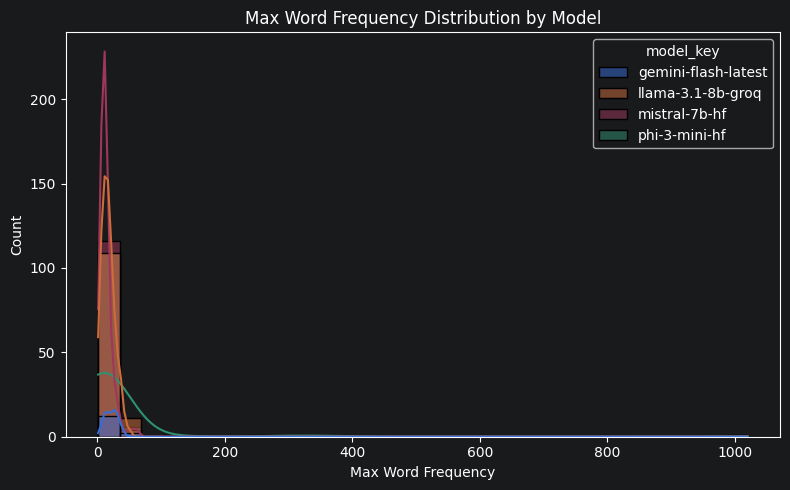

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["max_word_freq"] > 0],
    x="max_word_freq", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Max Word Frequency Distribution by Model")
ax.set_xlabel("Max Word Frequency")
plt.tight_layout()
plt.show()

### MTLD (Measure of Textual Lexical Diversity)

In [81]:
def get_mtld_score(text: str, threshold: float = 0.72) -> float:
    if not text:
        return 0

    lex = LexicalRichness(text)
    mtld_score = lex.mtld(threshold=threshold)

    return mtld_score

In [82]:
response_features["mtld"] = responses.apply(get_mtld_score)

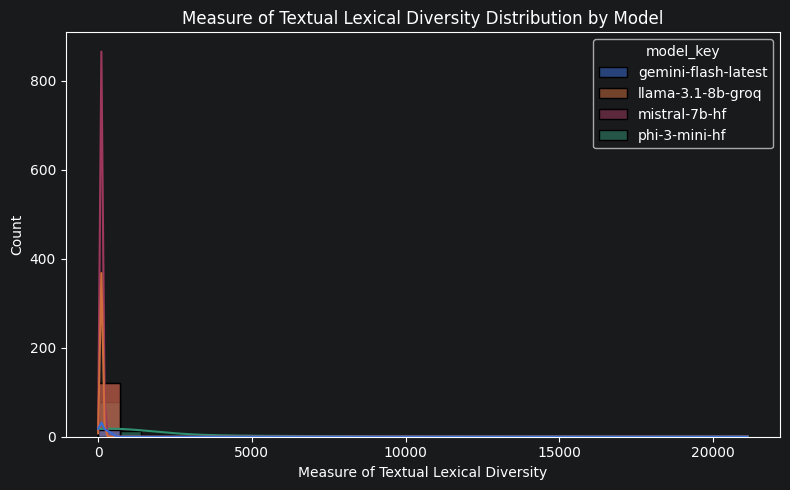

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["mtld"] > 0],
    x="mtld", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Measure of Textual Lexical Diversity Distribution by Model")
ax.set_xlabel("Measure of Textual Lexical Diversity")
plt.tight_layout()
plt.show()

### Lexical Density

In [84]:
def get_lexical_density(text: str, language: str="en") -> float:
    if not text:
        return 0

    if language == "pl":
        nlp = spacy.load("pl_core_news_sm")
    else:
        nlp = spacy.load("en_core_web_sm")

    doc = nlp(text)

    lexical_tags = {'NOUN', 'VERB', 'ADJ', 'ADV'}

    lexical_words = [token for token in doc if token.pos_ in lexical_tags]
    total_words = [token for token in doc if not token.is_punct]

    if len(total_words) > 0:
        lexical_density = len(lexical_words) / len(total_words)
    else:
        lexical_density = 0.0

    return lexical_density

In [85]:
response_features["lexical_density"] = llm_results_test_prompts_df.apply(
    lambda row: get_lexical_density(row["response"] if pd.notna(row["response"]) else "", row["language"]),
    axis=1
)

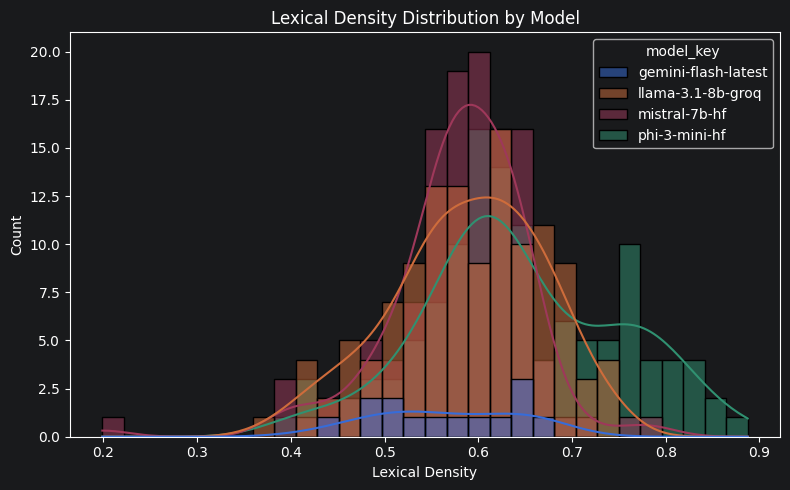

In [86]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["lexical_density"] > 0],
    x="lexical_density", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Lexical Density Distribution by Model")
ax.set_xlabel("Lexical Density")
plt.tight_layout()
plt.show()

## Stylistic and Semantic Features
### Sentiment analysis of responses

In [87]:
def get_sentiment_scores(text: str) -> tuple:
    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(text)

    negative_score = scores.get("neg", 0)
    neutral_score = scores.get("neu", 0)
    positive_score = scores.get("pos", 0)
    compound_score = scores.get("compound", 0)

    return negative_score, neutral_score, positive_score, compound_score

In [88]:
sentiment_scores = responses.apply(get_sentiment_scores)
response_features[["sentiment_negative", "sentiment_neutral", "sentiment_positive", "sentiment_compound"]] = pd.DataFrame(
    sentiment_scores.tolist(), index=response_features.index
)

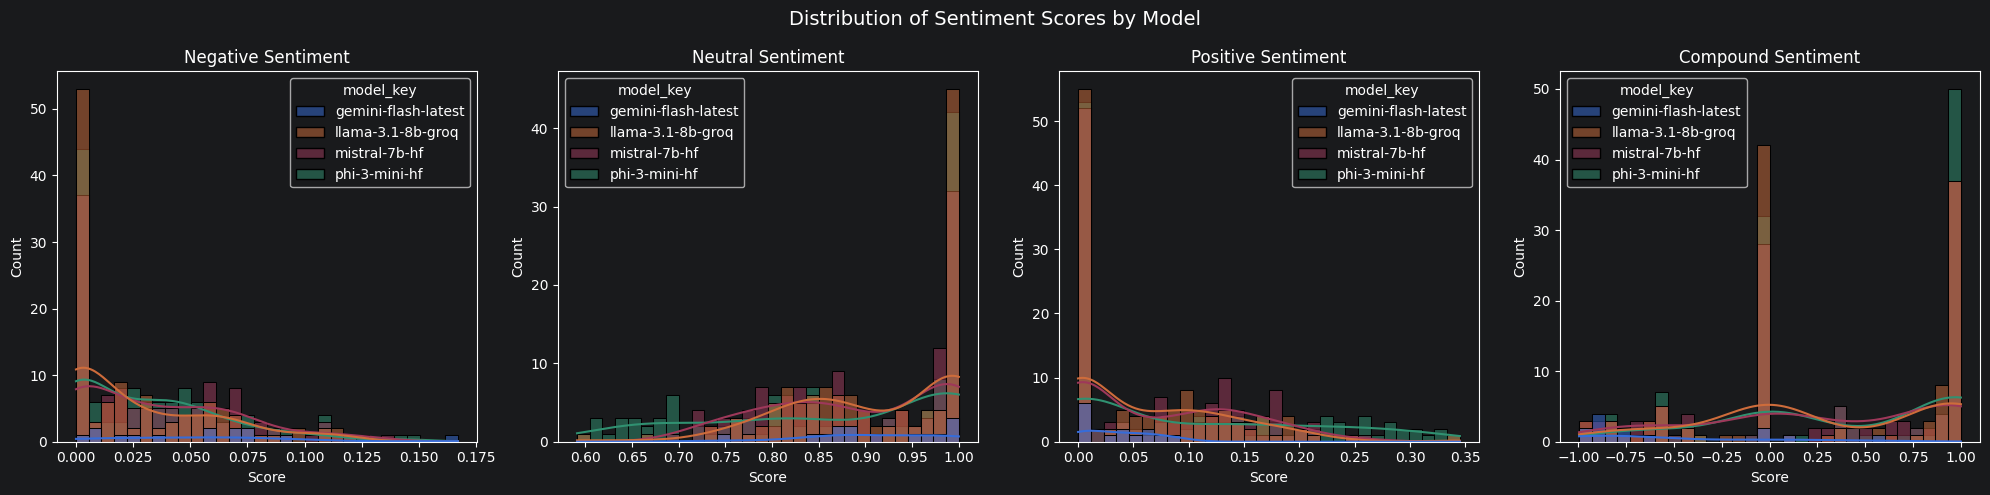

In [89]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sentiment_features = ["sentiment_negative", "sentiment_neutral", "sentiment_positive", "sentiment_compound"]
titles = ["Negative Sentiment", "Neutral Sentiment", "Positive Sentiment", "Compound Sentiment"]

for ax, feature, title in zip(axes, sentiment_features, titles):
    sns.histplot(
        data=response_features[response_features["response_length"] > 0],
        x=feature, hue="model_key", kde=True, ax=ax, bins=30, alpha=0.5
    )
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Sentiment Scores by Model", fontsize=14)
plt.tight_layout()
plt.show()

### Semantic Diversity

In [90]:
def calculate_semantic_diversity(text: str, sbert_model: SentenceTransformer) -> float:
    sentences = nltk.sent_tokenize(text)

    if len(sentences) < 2:
        return 0.0

    embeddings = sbert_model.encode(sentences)
    cosine_distances = pdist(embeddings, metric='cosine')
    scaled_distances = cosine_distances / 2.0

    return scaled_distances.mean()

In [91]:
model = SentenceTransformer('all-MiniLM-L6-v2')

response_features["semantic_diversity"] = responses.apply(
    lambda text: calculate_semantic_diversity(text, model)
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

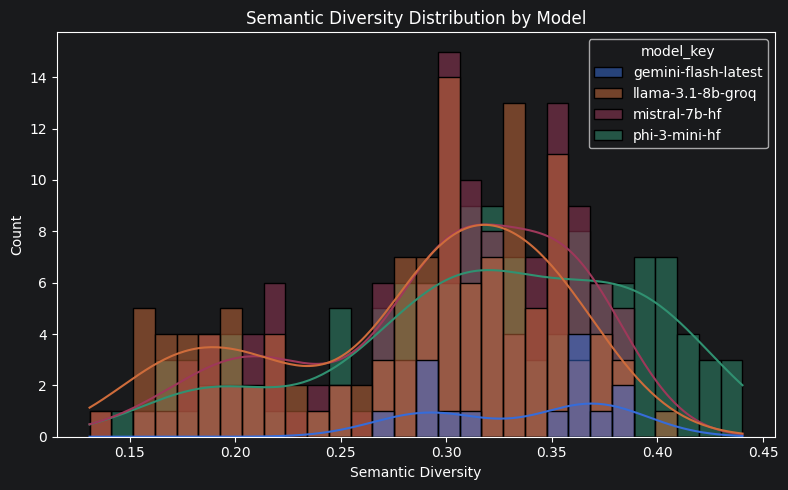

In [92]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["semantic_diversity"] > 0],
    x="semantic_diversity", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Semantic Diversity Distribution by Model")
ax.set_xlabel("Semantic Diversity")
plt.tight_layout()
plt.show()

### Density of first-person personal pronouns

In [93]:
def get_first_person_pronouns_count_and_density(text:str, language: str = "en") -> tuple:
    if language == "pl":
        nlp = spacy.load("pl_core_news_sm")
        first_person_lemmas = {'ja', 'my'}
    else:
        nlp = spacy.load("en_core_web_sm")
        first_person_lemmas = {'I', 'we'}

    doc = nlp(text)

    pronoun_count = sum(
        1 for token in doc
        if token.pos_ == 'PRON' and token.lemma_ in first_person_lemmas
    )

    total_words = len([token for token in doc if not token.is_punct])

    pronoun_density = pronoun_count / total_words if total_words > 0 else 0

    return pronoun_count, pronoun_density

In [94]:
first_person_results = llm_results_test_prompts_df.apply(
    lambda row: get_first_person_pronouns_count_and_density(
        row["response"] if pd.notna(row["response"]) else "", row["language"]
    ),
    axis=1
)
response_features[["first_person_pronoun_count", "first_person_pronoun_density"]] = pd.DataFrame(
    first_person_results.tolist(), index=response_features.index
)

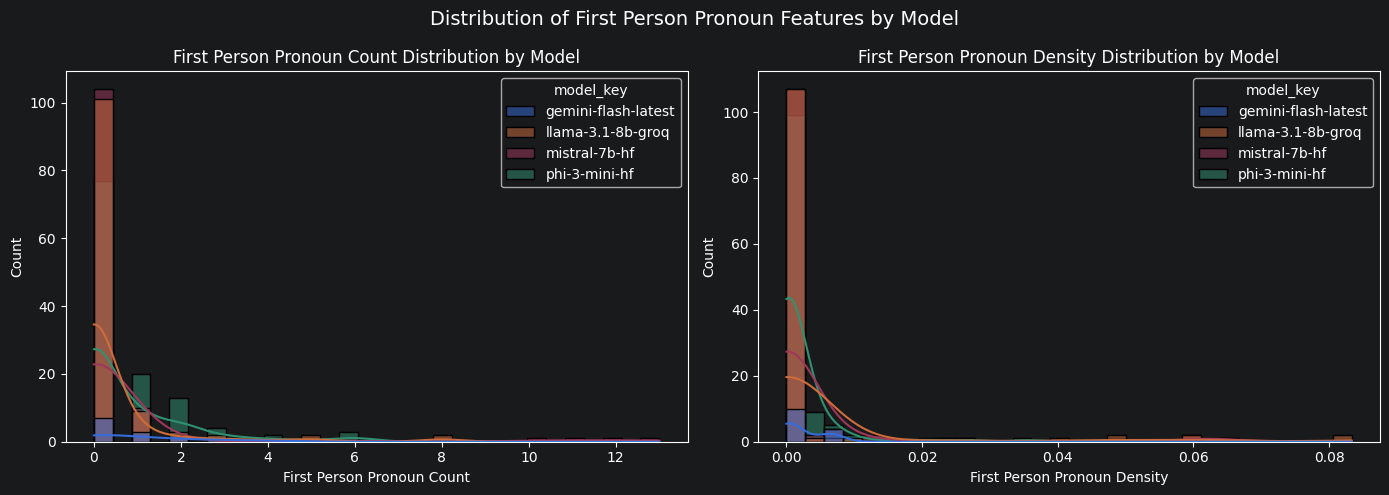

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["first_person_pronoun_count", "first_person_pronoun_density"]
titles = ["First Person Pronoun Count", "First Person Pronoun Density"]

for ax, feature, title in zip(axes, features, titles):
    sns.histplot(
        data=response_features[response_features["response_length"] > 0],
        x=feature, hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
    )
    ax.set_title(f"{title} Distribution by Model")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")

plt.suptitle("Distribution of First Person Pronoun Features by Model", fontsize=14)
plt.tight_layout()
plt.show()

## Readability Features
### Flesch Reading Ease

In [96]:
def get_flesch_reading_ease(text: str, language: str = "en"):
    if not text:
        return 0

    textstat.set_lang(language)
    fre = textstat.flesch_reading_ease(text)

    return fre

In [97]:
response_features["flesch_reading_ease"] = llm_results_test_prompts_df.apply(
    lambda row: get_flesch_reading_ease(row["response"] if pd.notna(row["response"]) else "", row["language"]),
    axis=1
)

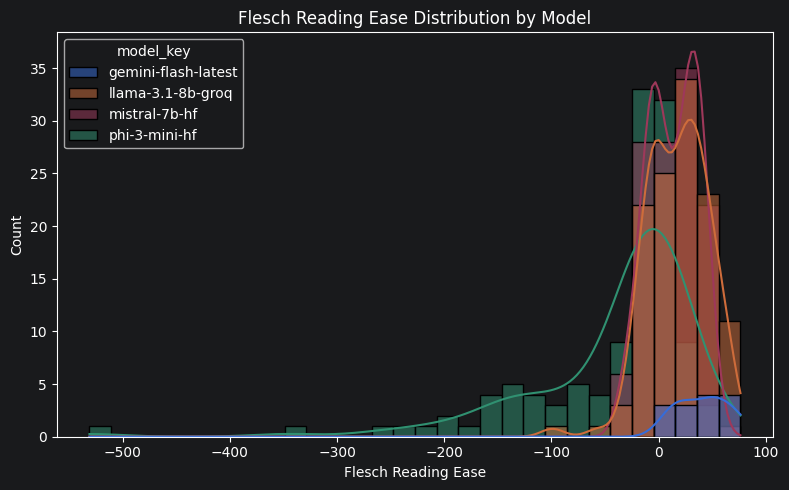

In [98]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["response_length"] > 0],
    x="flesch_reading_ease", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Flesch Reading Ease Distribution by Model")
ax.set_xlabel("Flesch Reading Ease")
plt.tight_layout()
plt.show()

### Flesch-Kincaid

In [99]:
def get_flesch_kincaid_grade(text: str, language: str = "en"):
    if not text:
        return 0

    textstat.set_lang(language)
    fkgl = textstat.flesch_kincaid_grade(text)

    return fkgl

In [100]:
response_features["flesch_kincaid_grade"] = llm_results_test_prompts_df.apply(
    lambda row: get_flesch_kincaid_grade(row["response"] if pd.notna(row["response"]) else "", row["language"]),
    axis=1
)

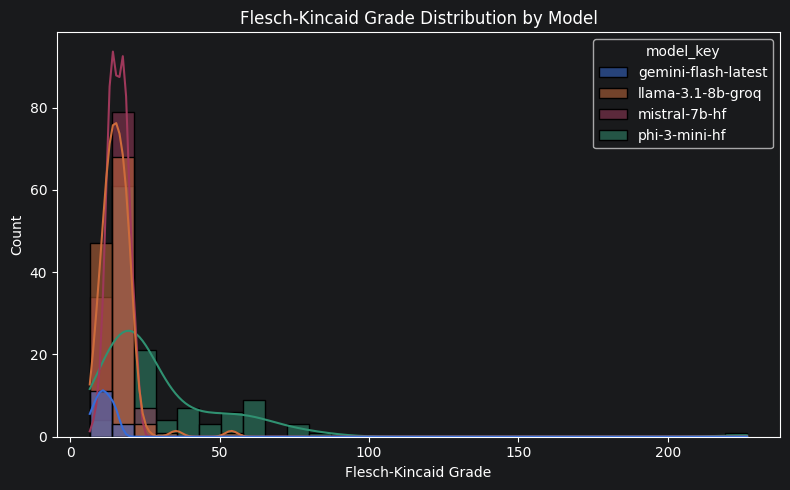

In [101]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["response_length"] > 0],
    x="flesch_kincaid_grade", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Flesch-Kincaid Grade Distribution by Model")
ax.set_xlabel("Flesch-Kincaid Grade")
plt.tight_layout()
plt.show()

### Gunning Fog

In [102]:
def get_gunning_fog(text: str, language: str = "en") -> float:
    if not text:
        return 0

    textstat.set_lang(language)
    fog = textstat.gunning_fog(text)

    return fog

In [103]:
response_features["gunning_fog"] = llm_results_test_prompts_df.apply(
    lambda row: get_gunning_fog(row["response"] if pd.notna(row["response"]) else "", row["language"]),
    axis=1
)

/home/dominika/Desktop/26L_sem8_mgr1/SIWY/LLM-Behavior-XAI/venv/lib64/python3.12/site-packages/textstat/backend/utils/_get_lang_easy_words.py:50: Warning: There is no easy words vocabulary for pl, using english.
  warnings.warn(


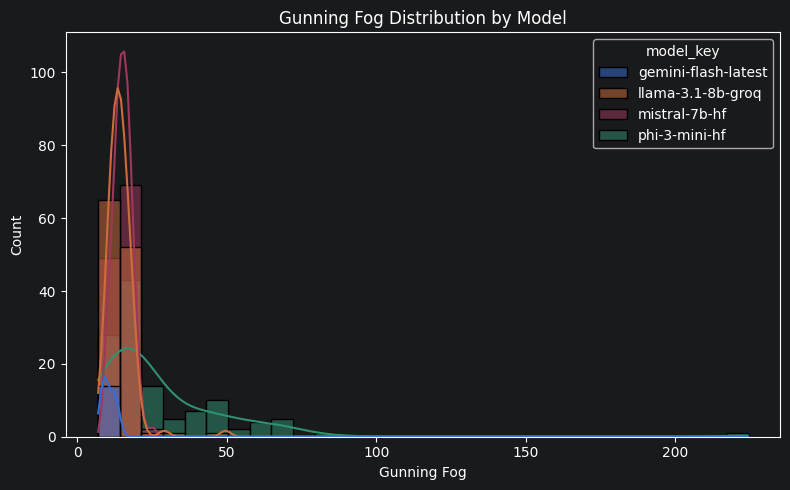

In [104]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=response_features[response_features["response_length"] > 0],
    x="gunning_fog", hue="model_key", kde=True, bins=30, alpha=0.5, ax=ax
)
ax.set_title("Gunning Fog Distribution by Model")
ax.set_xlabel("Gunning Fog")
plt.tight_layout()
plt.show()

## Correlation heatmap for response features

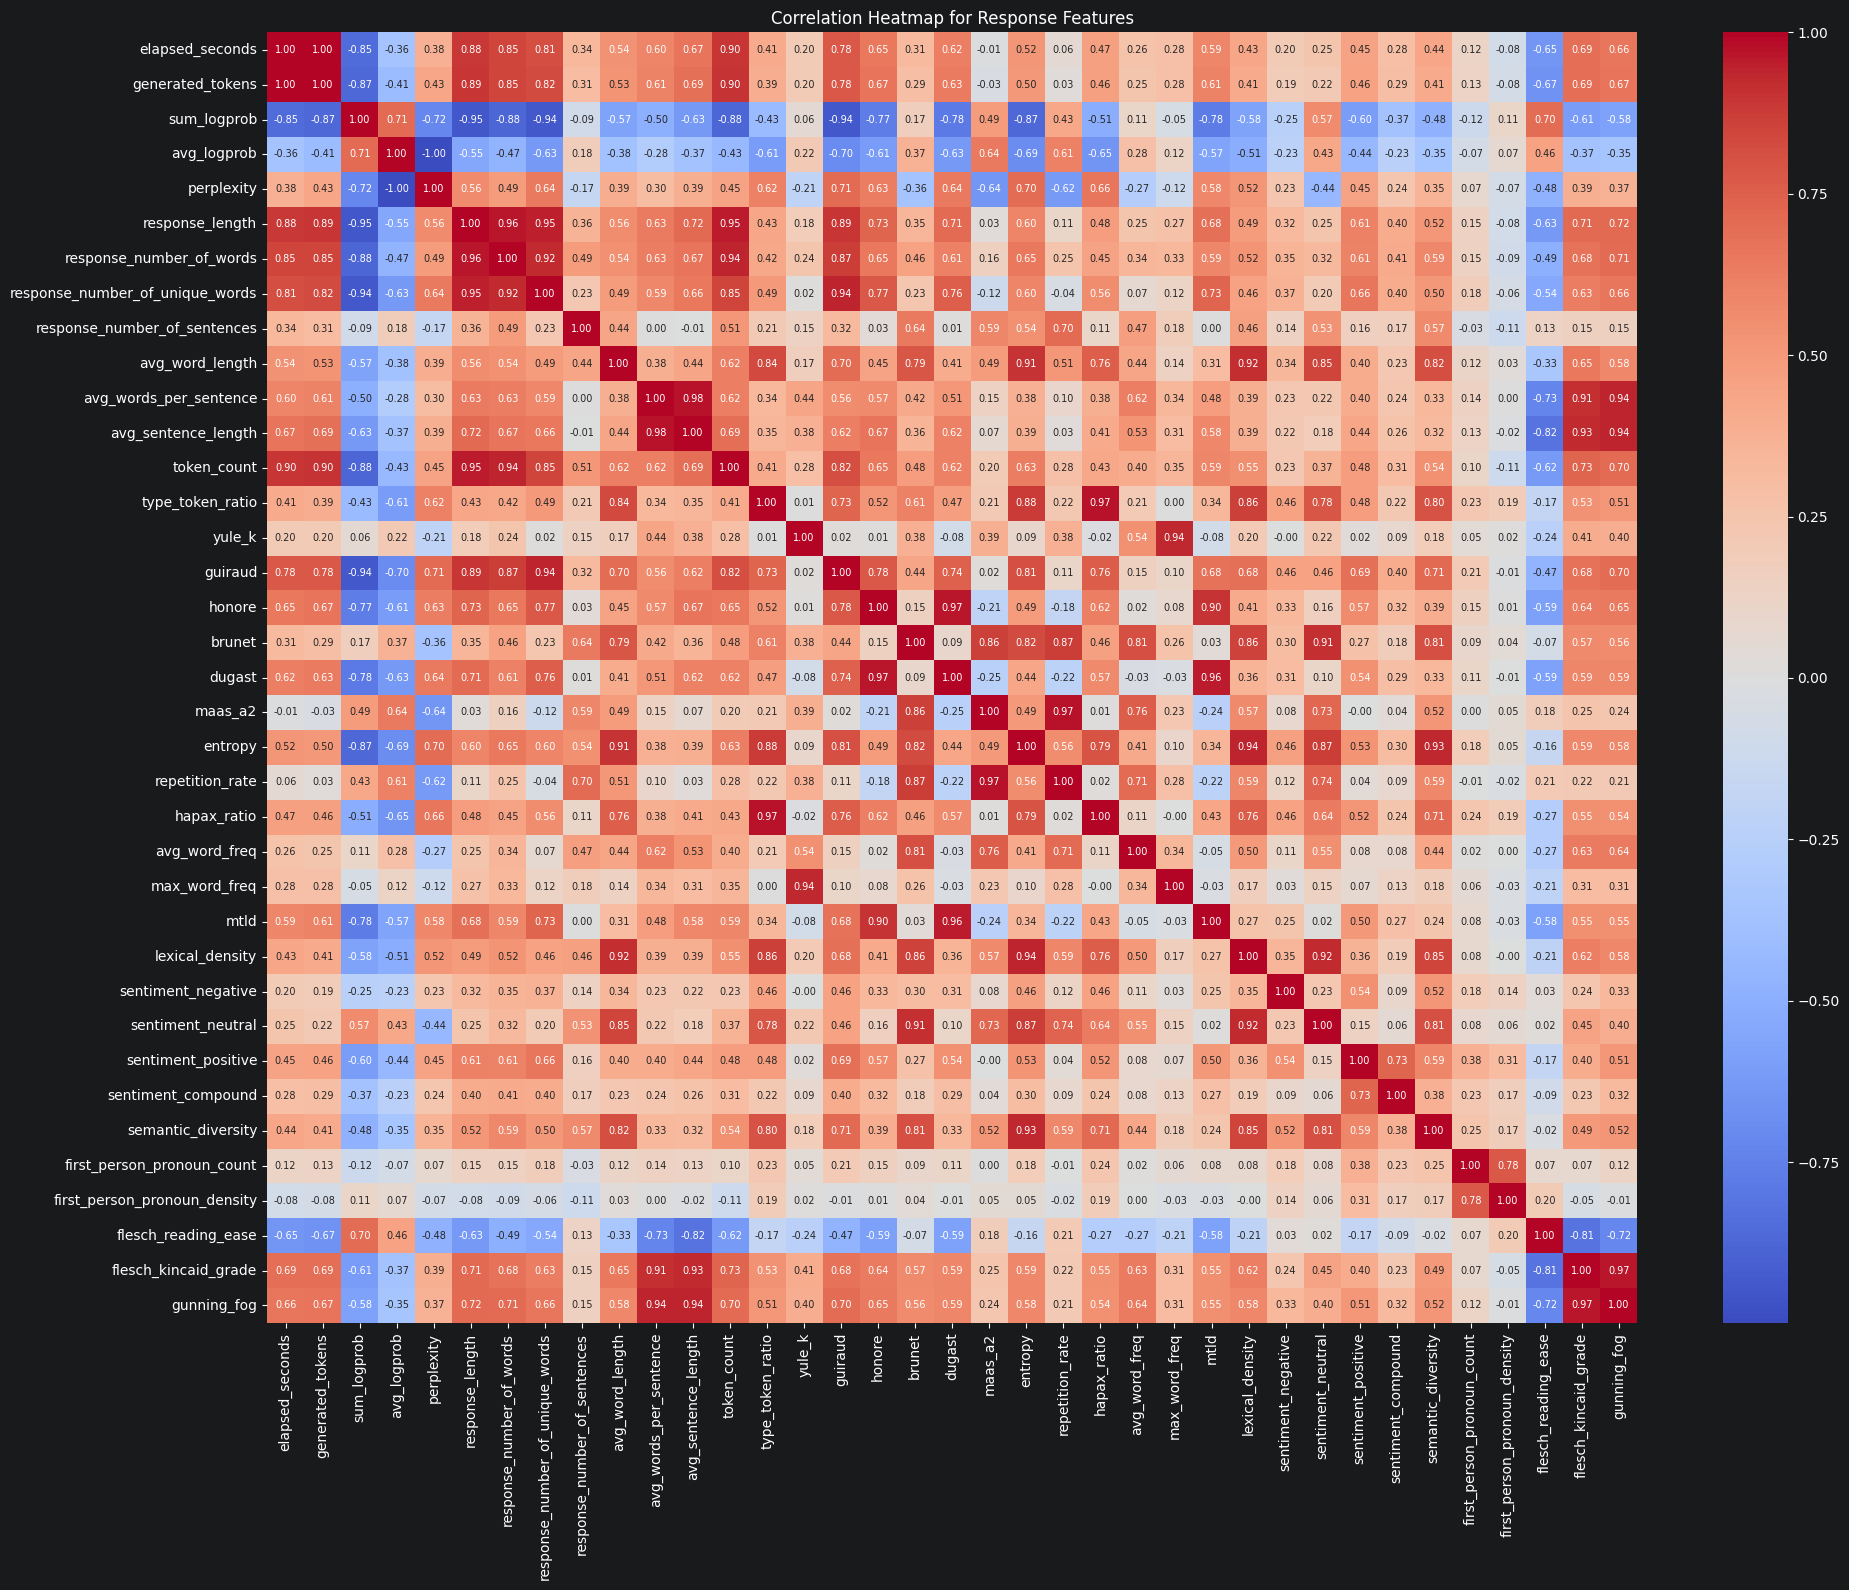

In [105]:
numeric_cols = response_features.select_dtypes(include="number").columns
corr = response_features[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Heatmap for Response Features")
plt.tight_layout()
plt.show()